## Configuration


The first step is to import the necessary libraries and to mount Drive in the notebook.

In [ ]:
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
!wget -q https://archive.apache.org/dist/spark/spark-3.0.1/spark-3.0.1-bin-hadoop2.7.tgz
!tar xf ./spark-3.0.1-bin-hadoop2.7.tgz
!pip install -q findspark

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import findspark

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.0.1-bin-hadoop2.7"
findspark.init()

## Spark session creation and connection with MongoDB

In [ ]:
from pyspark.sql import SparkSession
spark = SparkSession.builder\
        .master("local")\
        .appName("Colab")\
        .config('spark.ui.port', '4050') \
        .config("spark.jars.packages", 'org.mongodb.spark:mongo-spark-connector:10.0.4') \
        .getOrCreate()

In [ ]:
user=str(input('Inserire Utente: '))
pwd=str(input('Inserire Password: '))
indirizzo=str(input('Inserire Indirizzo Server: '))
database=str(input('Inserire Database: '))
collection=str(input('Inserire Collection: '))

data = spark.read.format("mongodb").option("spark.mongodb.connection.uri","mongodb://"+user+":"+pwd+"@"+indirizzo)\
.option("spark.mongodb.database",database)\
.option("spark.mongodb.collection", collection)\
.load()

In [ ]:
utente=""
password=""
indirizzo=""
database=""
collection="esempiomaster"

We print the schema of the collection that shows the attributes present in the source

In [ ]:
data.printSchema()

## EDA

The description of each feature can be found in: https://github.com/owid/energy-data/blob/master/owid-energy-codebook.csv We start with a description of the features to have an overall picture. We then pass to filter the dataset to select the attributes that better describe the consumption of

In [ ]:
data.describe().show()

+-------+--------------------+-----------------------+-----------------------+-----------------------+-------------------+-----------------------+-------------------+------------------+--------------------+---------------------+--------------------+--------------------+--------------------+-----------------+--------------------+------------------+--------------------+--------------------+--------------------+-----------------+------------------+------------------+-----------+------------------+----------------------+----------------------+----------------------+------------------+------------------+----------------------+----------------------+----------------------+------------------+------------------------+-----------------------+-----------------+-------------------+-------------------+-------------------+------------------+-------------------+------------------+---------------------+--------------------+-------------------+-------------------+------------------+-----------------+-

In [ ]:
#filter per anno e colone)
df = data.filter(data.year >= 2000).select('country','year','coal_production','electricity_generation','biofuel_electricity','coal_electricity','fossil_electricity','gas_electricity','hydro_electricity','nuclear_electricity','oil_electricity','renewables_electricity','oil_production','population','gdp','solar_electricity','wind_electricity','energy_per_gdp','energy_per_capita','fossil_share_elec','gas_share_elec','gas_production','low_carbon_share_elec').alias('df')

In [ ]:
countries=['Italy','Egypt','Saudi Arabia','United Kingdom','France','Germany','United States','Japan','India','Argentina']
df_finale = df.filter(df.country.isin(countries)).alias('df_finale')

In [ ]:
df_finale.describe().show()

+-------+-------------+-----------------+------------------+----------------------+-------------------+-----------------+------------------+------------------+-----------------+-------------------+-----------------+----------------------+------------------+--------------------+--------------------+------------------+------------------+-------------------+-----------------+------------------+------------------+-----------------+---------------------+
|summary|      country|             year|   coal_production|electricity_generation|biofuel_electricity| coal_electricity|fossil_electricity|   gas_electricity|hydro_electricity|nuclear_electricity|  oil_electricity|renewables_electricity|    oil_production|          population|                 gdp| solar_electricity|  wind_electricity|     energy_per_gdp|energy_per_capita| fossil_share_elec|    gas_share_elec|   gas_production|low_carbon_share_elec|
+-------+-------------+-----------------+------------------+----------------------+---------

We count the quantity of null or nan values per column to undestand in which ones we need to fill this types of values with the Foward-fill technique (filling null values with the last known non-null value)

In [ ]:
from pyspark.sql.functions import isnan, when, count, col
df_finale.select([count(when(isnan(c) | col(c).isNull(), c)).alias(c) for c in df_finale.columns]).show()

+-------+----+---------------+----------------------+-------------------+----------------+------------------+---------------+-----------------+-------------------+---------------+----------------------+--------------+----------+---+-----------------+----------------+--------------+-----------------+-----------------+--------------+--------------+---------------------+
|country|year|coal_production|electricity_generation|biofuel_electricity|coal_electricity|fossil_electricity|gas_electricity|hydro_electricity|nuclear_electricity|oil_electricity|renewables_electricity|oil_production|population|gdp|solar_electricity|wind_electricity|energy_per_gdp|energy_per_capita|fossil_share_elec|gas_share_elec|gas_production|low_carbon_share_elec|
+-------+----+---------------+----------------------+-------------------+----------------+------------------+---------------+-----------------+-------------------+---------------+----------------------+--------------+----------+---+-----------------+--------

In [ ]:
from pyspark.sql import Window
from pyspark.sql.functions import last
import sys

# define the window
window = Window.partitionBy('country')\
               .orderBy('year')\
               .rowsBetween(-sys.maxsize, 0)

# define the forward-filled column
filled_column_gdp = last(df_finale['gdp'], ignorenulls=True).over(window)
filled_column_coal_production = last(df_finale['coal_production'], ignorenulls=True).over(window)
filled_column_oil_production = last(df_finale['oil_production'], ignorenulls=True).over(window)
filled_column_energy_per_gdp = last(df_finale['energy_per_gdp'], ignorenulls=True).over(window)
filled_column_gas_production = last(df_finale['gas_production'], ignorenulls=True).over(window)

# do the fill
df_filled = df_finale.withColumn('gdp_filled', filled_column_gdp)
df_filled = df_filled.withColumn('coal_production_filled', filled_column_coal_production)
df_filled = df_filled.withColumn('oil_production_filled', filled_column_oil_production)
df_filled = df_filled.withColumn('energy_per_gdp_filled', filled_column_energy_per_gdp)
df_filled = df_filled.withColumn('gas_production_filled', filled_column_gas_production)

In [ ]:
#mostrare come si sostituisce il null
df_filled.orderBy('country','year').select('country','year','gdp','gdp_filled','coal_production','coal_production_filled','oil_production','oil_production_filled').show(30)

+---------+----+----------------+----------------+---------------+----------------------+--------------+---------------------+
|  country|year|             gdp|      gdp_filled|coal_production|coal_production_filled|oil_production|oil_production_filled|
+---------+----+----------------+----------------+---------------+----------------------+--------------+---------------------+
|Argentina|2000|5.36481038336E11|5.36481038336E11|          1.702|                 1.702|       480.871|              480.871|
|Argentina|2001|5.15221291008E11|5.15221291008E11|          1.222|                 1.222|       510.896|              510.896|
|Argentina|2002|4.61203406848E11|4.61203406848E11|          0.302|                 0.302|       503.277|              503.277|
|Argentina|2003|5.04301027328E11|5.04301027328E11|          0.585|                 0.585|       501.183|              501.183|
|Argentina|2004|5.52377778176E11|5.52377778176E11|          0.335|                 0.335|        477.13|       

Now that the data is cleaned and we selected the features to analyze we pass to make some descriptive analysis. We start with the creation of the correlation matrix/heatmap.

In [ ]:
####STADISTIC DESC##########

from pyspark.ml.stat import Correlation
from pyspark.ml.linalg import DenseMatrix, Vectors
from pyspark.ml.feature import VectorAssembler
from pyspark.sql.functions import *

df_complete = df_filled.select([c for c in df.columns if c not in {'year','country','gdp','coal_production','oil_production','energy_per_gdp','gas_production'}]).alias('df_complete')
assembler = VectorAssembler(inputCols=df_complete.columns, outputCol="features",handleInvalid='keep')
df = assembler.transform(df_complete).select("features")

# correlation will be in Dense Matrix
correlation = Correlation.corr(df,"features","pearson").collect()[0][0]

# To convert Dense Matrix into DataFrame
rows = correlation.toArray().tolist()
df = spark.createDataFrame(rows,df_complete.columns)
df.show()

+----------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+----------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+---------------------+
|electricity_generation| biofuel_electricity|    coal_electricity|  fossil_electricity|     gas_electricity|   hydro_electricity| nuclear_electricity|     oil_electricity|renewables_electricity|          population|   solar_electricity|    wind_electricity|   energy_per_capita|   fossil_share_elec|      gas_share_elec|low_carbon_share_elec|
+----------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+----------------------+--------------------+--------------------+--------------------+--------------------+--------------------+---------------

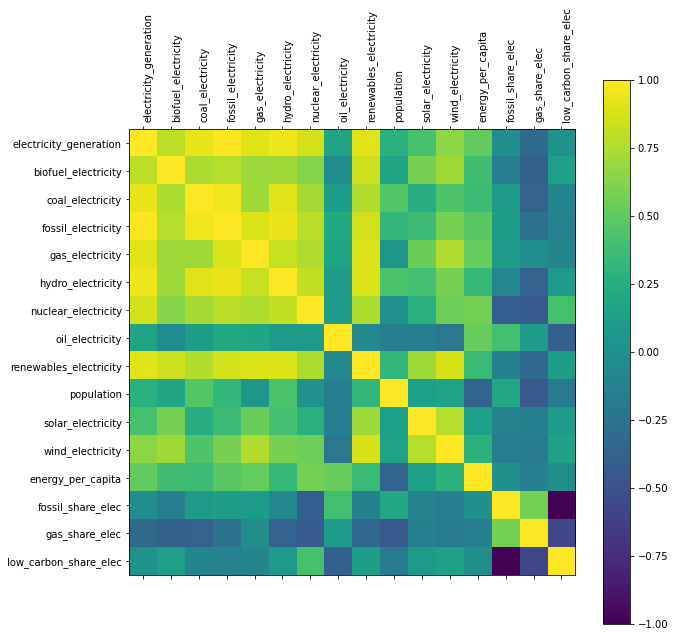

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
def plot_corr_matrix(correlations,attr,fig_no):
    fig=plt.figure(fig_no,figsize=(10, 10))
    ax=fig.add_subplot(111)
    ax.set_xticklabels(['']+attr, rotation=90, ha='left')
    ax.set_yticklabels(['']+attr)
    cax=ax.matshow(correlations,vmax=1,vmin=-1)
    ax.yaxis.set_major_locator(MultipleLocator(1))  #to show all labels
    ax.xaxis.set_major_locator(MultipleLocator(1))  
    fig.colorbar(cax)
    plt.show()

plot_corr_matrix(rows, df_complete.columns, 234)

We will now made some analysis of the gdp and gdp per capita in specific counties. After this we can pass to an analysis of one country at a time to see how the use of different sources of energy has change in the past years (since 2000)

In [ ]:
DF = df_filled.toPandas()
#filtered_by_gender_m = transactions_df.filter(F.col('gender') == 'M').select(F.col('amount').alias('amount_m'))

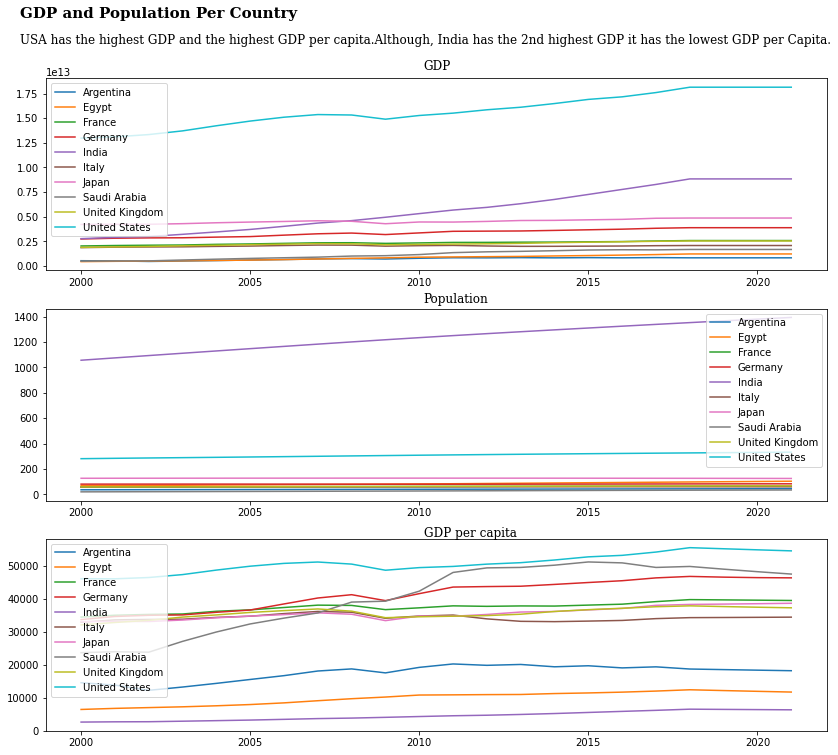

In [ ]:
# lets plot the gdp , population and gdp per capita  per country
DF_gdp=DF.groupby(['year','country'])['gdp_filled'].sum().unstack('country')
DF_pop=DF.groupby(['year','country'])['population'].sum().unstack('country')
DF_pop_mil=(DF_pop/1000000)
DF['gdp_per_capita']=(DF['gdp_filled']/DF['population'])
DF_gdp_per_capita=DF.groupby(['year','country'])['gdp_per_capita'].sum().unstack('country')
fig, ax = plt.subplots(3, 1, figsize=(14, 12))

ax[0].plot(DF_gdp)
ax[0].legend(DF_gdp.columns)
ax[1].plot(DF_pop_mil)
ax[1].legend(DF_pop_mil.columns)
ax[2].plot(DF_gdp_per_capita)
ax[2].legend(DF_gdp_per_capita)


fig.text(0.1, 0.95, 'GDP and Population Per Country', fontsize=15, fontweight='bold', fontfamily='serif')
fig.text(0.1, 0.92, '''USA has the highest GDP and the highest GDP per capita.Although, India has the 2nd highest GDP it has the lowest GDP per Capita.'''
, fontsize=12, fontweight='light', fontfamily='serif')
fig.text(0.5, 0.89, '''GDP''', fontsize=12, fontweight='light', fontfamily='serif')
fig.text(0.5, 0.62,'''Population''', fontsize=12, fontweight='light', fontfamily='serif')
fig.text(0.5, 0.35,'''GDP per capita''', fontsize=12, fontweight='light', fontfamily='serif')

plt.show()

**Germany** analysis:

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/usr/local/lib/python3.7/dist-packages/pandas/core/frame.py:4913: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors=errors,


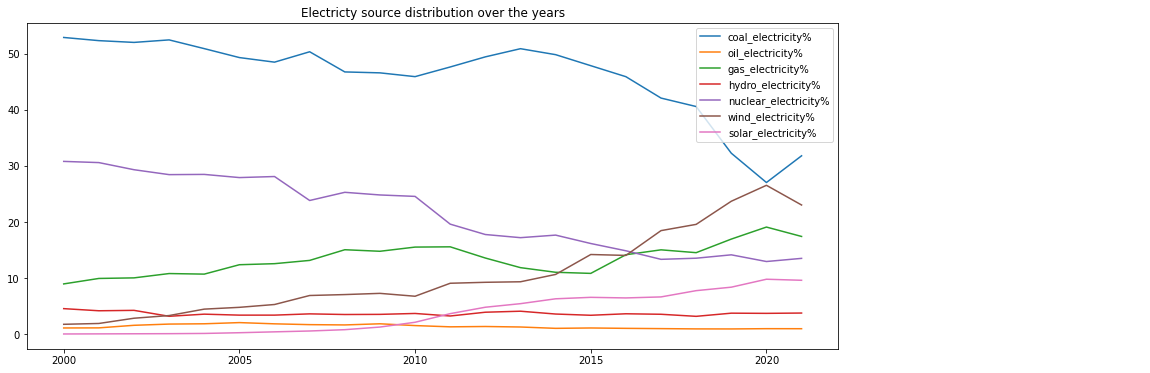

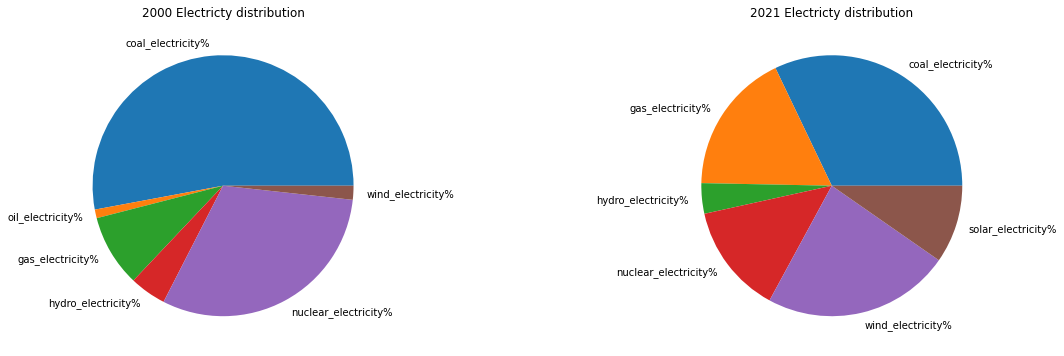

In [ ]:
# get the % share of electricty from total energy sources 
Parse=['coal_electricity','oil_electricity','gas_electricity','hydro_electricity','nuclear_electricity','wind_electricity','solar_electricity']
DF['total']=DF[Parse].sum(axis=1)
DF_Electricity=DF[['year','country']]
for i in Parse:
    DF_Electricity[f"{i}%"]=100*(DF[i]/DF['total'])
# plot the change in the percentage over the years
fig3, ax3 = plt.subplots(1, 2, figsize=(20, 6),gridspec_kw={'width_ratios':[4,1]})
chart_DF=DF_Electricity[DF_Electricity['country']=='Germany'].groupby('year').mean()
ax3[0].plot(chart_DF)
ax3[0].set_title("Electricty source distribution over the years")
ax3[0].legend(chart_DF.columns)
ax3[1].axis('off')
    
    

#plot the pie charts for energy distribution and compare 2000 Vs 2021
#but for the pie charts its better to drop the columns with zero values to not affect the labeling
years=[2000,2021]
count=0
fig4,ay3 =  plt.subplots(1, 2, figsize=(20, 6))
for y in years:
    chart_DF_pie_1=chart_DF[(chart_DF.index.values==y)]
    for i in chart_DF_pie_1.columns:
        if chart_DF_pie_1.iloc[0][i]<1:
            chart_DF_pie_1.drop(columns=[i],axis=1,inplace=True)
    ay3[count].pie(chart_DF_pie_1.iloc[0].values,labels=chart_DF_pie_1.columns)
    ay3[count].set_title(f"{int(y)} Electricty distribution")
    count=count+1

plt.show()

**If we compare the trends in 2011, we can see that germany reduced its reliance on nuclear energy. Perhaps its due to the Fukushima disaster? Germany also changed its strategy for energy sources to renewable sources. That is evident after 2015 were wind became is the 2nd primary energy source.**

**Japan** analysis:

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


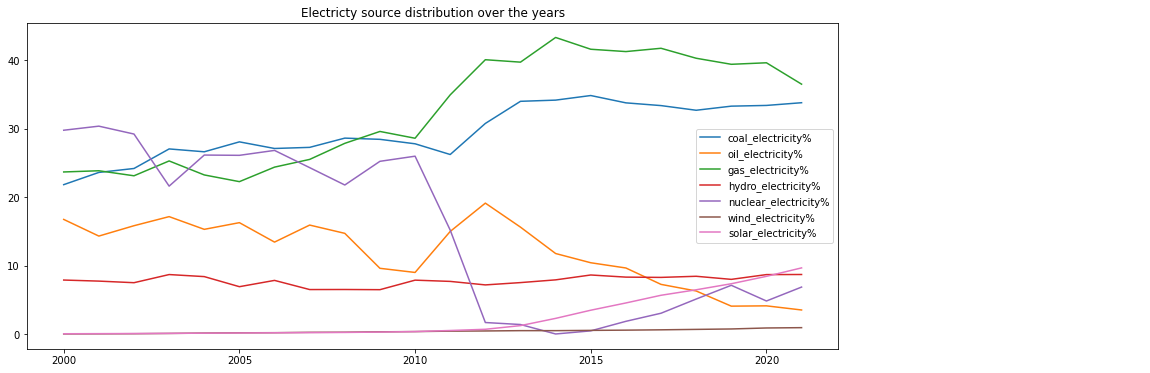

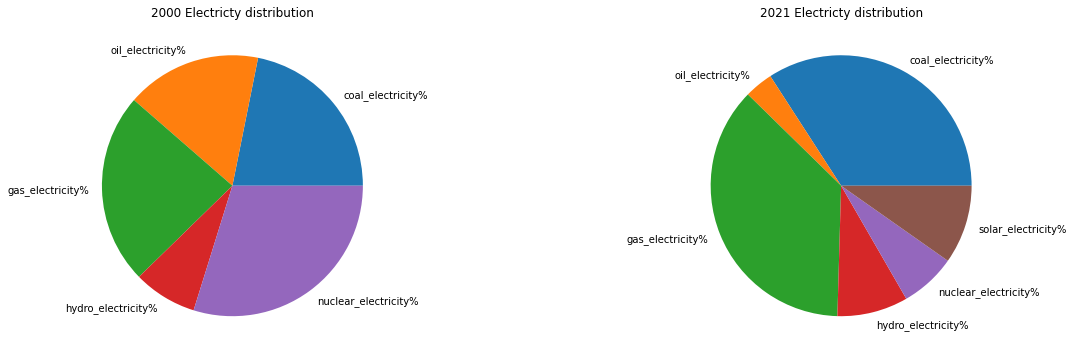

In [ ]:
# get the % share of electricty from total energy sources 
Parse=['coal_electricity','oil_electricity','gas_electricity','hydro_electricity','nuclear_electricity','wind_electricity','solar_electricity']
DF['total']=DF[Parse].sum(axis=1)
DF_Electricity=DF[['year','country']]
for i in Parse:
    DF_Electricity[f"{i}%"]=100*(DF[i]/DF['total'])
# plot the change in the percentage over the years
fig3, ax3 = plt.subplots(1, 2, figsize=(20, 6),gridspec_kw={'width_ratios':[4,1]})
chart_DF=DF_Electricity[DF_Electricity['country']=='Japan'].groupby('year').mean()
ax3[0].plot(chart_DF)
ax3[0].set_title("Electricty source distribution over the years")
ax3[0].legend(chart_DF.columns)
ax3[1].axis('off')
    
    

#plot the pie charts for energy distribution and compare 2000 Vs 2021
#but for the pie charts its better to drop the columns with zero values to not affect the labeling
years=[2000,2021]
count=0
fig4,ay3 =  plt.subplots(1, 2, figsize=(20, 6))
for y in years:
    chart_DF_pie_1=chart_DF[(chart_DF.index.values==y)]
    for i in chart_DF_pie_1.columns:
        if chart_DF_pie_1.iloc[0][i]<1:
            chart_DF_pie_1.drop(columns=[i],axis=1,inplace=True)
    ay3[count].pie(chart_DF_pie_1.iloc[0].values,labels=chart_DF_pie_1.columns)
    ay3[count].set_title(f"{int(y)} Electricty distribution")
    count=count+1

plt.show()

**After the Fukushima disater in Japan 2011 were 4 reactor buildings exploded, Japan changed its strategy for energy sources and became more reliant on coal and gas.**

# EVOLUTION OF RENEWABLE ENERGY CONSUMPTION FROM 1970 TO 2021. FIRST AT THE GLOBAL LEVEL AND THEN AT ITALY LEVEL
 

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:6: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:19: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.


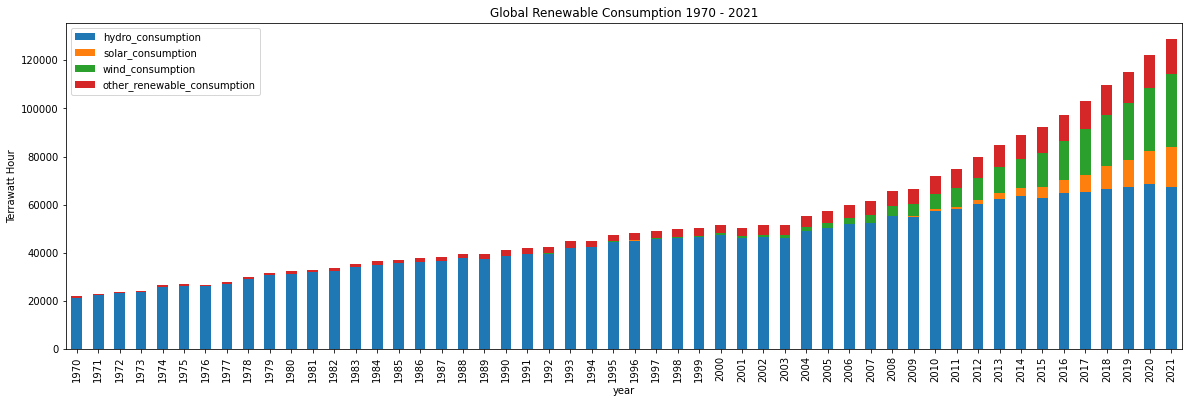

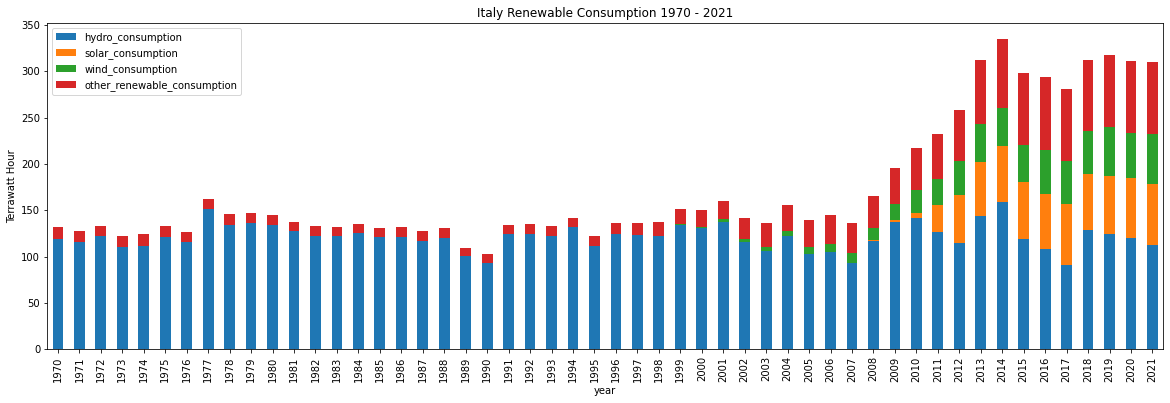

In [ ]:
# Total Renewable Energy Consumption
energy_df = data.filter(data.year>=1970).select("iso_code","country", "year", "renewables_consumption","other_renewable_consumption","hydro_consumption","solar_consumption","wind_consumption").alias("energy_df")
ENERGY = energy_df.toPandas()

# Create dataframe for yearly energy consumption
bar=ENERGY.groupby('year')["hydro_consumption","solar_consumption","wind_consumption","other_renewable_consumption"].sum()
bar.reset_index(level=0, inplace=True)

# Plot stacked bar chart
bar.plot(x='year', ylabel='Terrawatt Hour', kind='bar', stacked=True,figsize=(20,6),title='Global Renewable Consumption 1970 - 2021')

#For Italy
countries=['Italy']
energy_df_ita = data.filter(data.year>=1970).select("iso_code","country", "year", "renewables_consumption","other_renewable_consumption","hydro_consumption","solar_consumption","wind_consumption").alias("energy_df")
energy_df_finale_ita = energy_df.filter(energy_df_ita.country.isin(countries)).alias('energy_df_finale_ita')
ENERGY = energy_df_finale_ita.toPandas()

# Create dataframe for yearly energy consumption
bar=ENERGY.groupby('year')["hydro_consumption","solar_consumption","wind_consumption","other_renewable_consumption"].sum()
bar.reset_index(level=0, inplace=True)

# Plot stacked bar chart
bar.plot(x='year', ylabel='Terrawatt Hour', kind='bar', stacked=True,figsize=(20,6),title='Italy Renewable Consumption 1970 - 2021')

## PERCENTAGE CALCULATION FOR EACH SOURCE FOR THE YEAR 2020




In [ ]:
from pyspark.sql.functions import expr
data_energia = data.filter(data.year==2020).select('country', 
           'year',
           'biofuel_electricity', 
           'hydro_electricity',
           'nuclear_electricity',
           'solar_electricity',
           'wind_electricity', 
           'other_renewable_electricity',
           'coal_electricity',
           'gas_electricity',
           'oil_electricity').alias("data_energia")

data_energia = data_energia.withColumn('total', expr("biofuel_electricity + hydro_electricity + nuclear_electricity + solar_electricity+ wind_electricity + other_renewable_electricity + coal_electricity + gas_electricity + oil_electricity "))


In [ ]:
from pyspark.sql.functions import round
data_energia=data_energia.withColumn('biofuel_perc', (round((100*(data_energia.biofuel_electricity/data_energia.total)),2)))
data_energia=data_energia.withColumn('hydro_perc', (round((100*(data_energia.hydro_electricity/data_energia.total)),2)))
data_energia=data_energia.withColumn('nuclear_perc', (round((100*(data_energia.nuclear_electricity/data_energia.total)),2)))
data_energia=data_energia.withColumn('solar_perc', (round((100*(data_energia.solar_electricity/data_energia.total)),2)))
data_energia=data_energia.withColumn('wind_perc', (round((100*(data_energia.wind_electricity/data_energia.total)),2)))
data_energia=data_energia.withColumn('other_renewable_perc', (round((100*(data_energia.other_renewable_electricity/data_energia.total)),2)))
data_energia=data_energia.withColumn('coal_perc', (round((100*(data_energia.coal_electricity/data_energia.total)),2)))
data_energia=data_energia.withColumn('gas_perc', (round((100*(data_energia.gas_electricity/data_energia.total)),2)))
data_energia=data_energia.withColumn('oil_perc', (round((100*(data_energia.oil_electricity/data_energia.total)),2)))

In [ ]:
data_energia = data_energia.withColumn('renewable', expr("biofuel_perc + hydro_perc + nuclear_perc + solar_perc+ wind_perc + other_renewable_perc "))
data_energia = data_energia.withColumn('not_renewable', expr("coal_perc + gas_perc + oil_perc "))

In [ ]:
data_energia=data_energia.na.drop()
data_energia_renewables=data_energia.orderBy("renewable", ascending=False)
data_energia_not_renewables=data_energia.orderBy("not_renewable", ascending=False)

c=data_energia.select("country", "renewable", "not_renewable").alias("c")

CONTEGGIO DI NAZIONI PER OGNI RANGE 
 bins
0%        24
1-25%     73
26-75%    91
75-99%    30
100%       9
dtype: int64


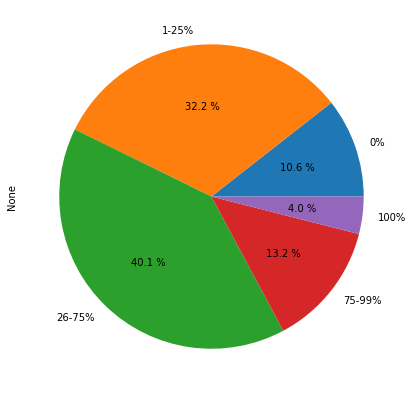

In [ ]:
import pandas as pd

datasetprova=c.toPandas()

datasetprova['bins'] = pd.cut(datasetprova['renewable'],bins=[-1,0,25,75,99,101], labels=["0%","1-25%","26-75%","75-99%", "100%"])

a = datasetprova.groupby('bins').size()
print("CONTEGGIO DI NAZIONI PER OGNI RANGE \n", a)
a.plot.pie(y="% renewables", legend=False, autopct='%1.1f %%', figsize=(7,7))


# SPARK ML

In [ ]:
from pyspark.ml.feature import VectorAssembler
assemble=VectorAssembler(inputCols=[
'biofuel_perc',
'hydro_perc',
'nuclear_perc',
'solar_perc',
'wind_perc',
'other_renewable_perc',
'coal_perc',
'gas_perc',
'oil_perc'],outputCol = 'energy_features')

assembled_data=assemble.transform(data_energia)


In [ ]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

silhouette_scores=[]
evaluator = ClusteringEvaluator(featuresCol='energy_features', \
metricName='silhouette', distanceMeasure='squaredEuclidean')

for K in range(2,11):

    KMeans_=KMeans(featuresCol='energy_features', k=K)

    KMeans_fit=KMeans_.fit(assembled_data)

    KMeans_transform=KMeans_fit.transform(assembled_data) 

    evaluation_score=evaluator.evaluate(KMeans_transform)

    silhouette_scores.append(evaluation_score)


Text(0, 0.5, 'Silhouette Score')

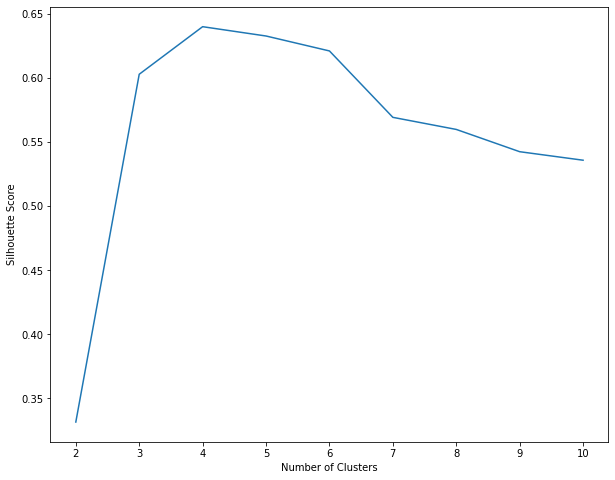

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1,1, figsize =(10,8))
ax.plot(range(2,11),silhouette_scores)
ax.set_xlabel('Number of Clusters')
ax.set_ylabel('Silhouette Score')

In [ ]:
KMeans_=KMeans(featuresCol='energy_features', k=4) 
KMeans_Model=KMeans_.fit(assembled_data)
KMeans_Assignments=KMeans_Model.transform(assembled_data)

In [ ]:
KMeans_Assignments.show()

+-------------------+----+-------------------+-----------------+-------------------+-----------------+----------------+---------------------------+----------------+---------------+---------------+------------------+------------+----------+------------+----------+---------+--------------------+---------+--------+--------+------------------+------------------+--------------------+----------+
|            country|year|biofuel_electricity|hydro_electricity|nuclear_electricity|solar_electricity|wind_electricity|other_renewable_electricity|coal_electricity|gas_electricity|oil_electricity|             total|biofuel_perc|hydro_perc|nuclear_perc|solar_perc|wind_perc|other_renewable_perc|coal_perc|gas_perc|oil_perc|         renewable|     not_renewable|     energy_features|prediction|
+-------------------+----+-------------------+-----------------+-------------------+-----------------+----------------+---------------------------+----------------+---------------+---------------+------------------

In [ ]:
a=KMeans_Assignments.select('biofuel_perc',
'hydro_perc',
'nuclear_perc',
'solar_perc',
'wind_perc',
'prediction','other_renewable_perc',
'coal_perc',
'gas_perc',
'oil_perc').alias("a")

In [ ]:
clusters_data=a.toPandas()

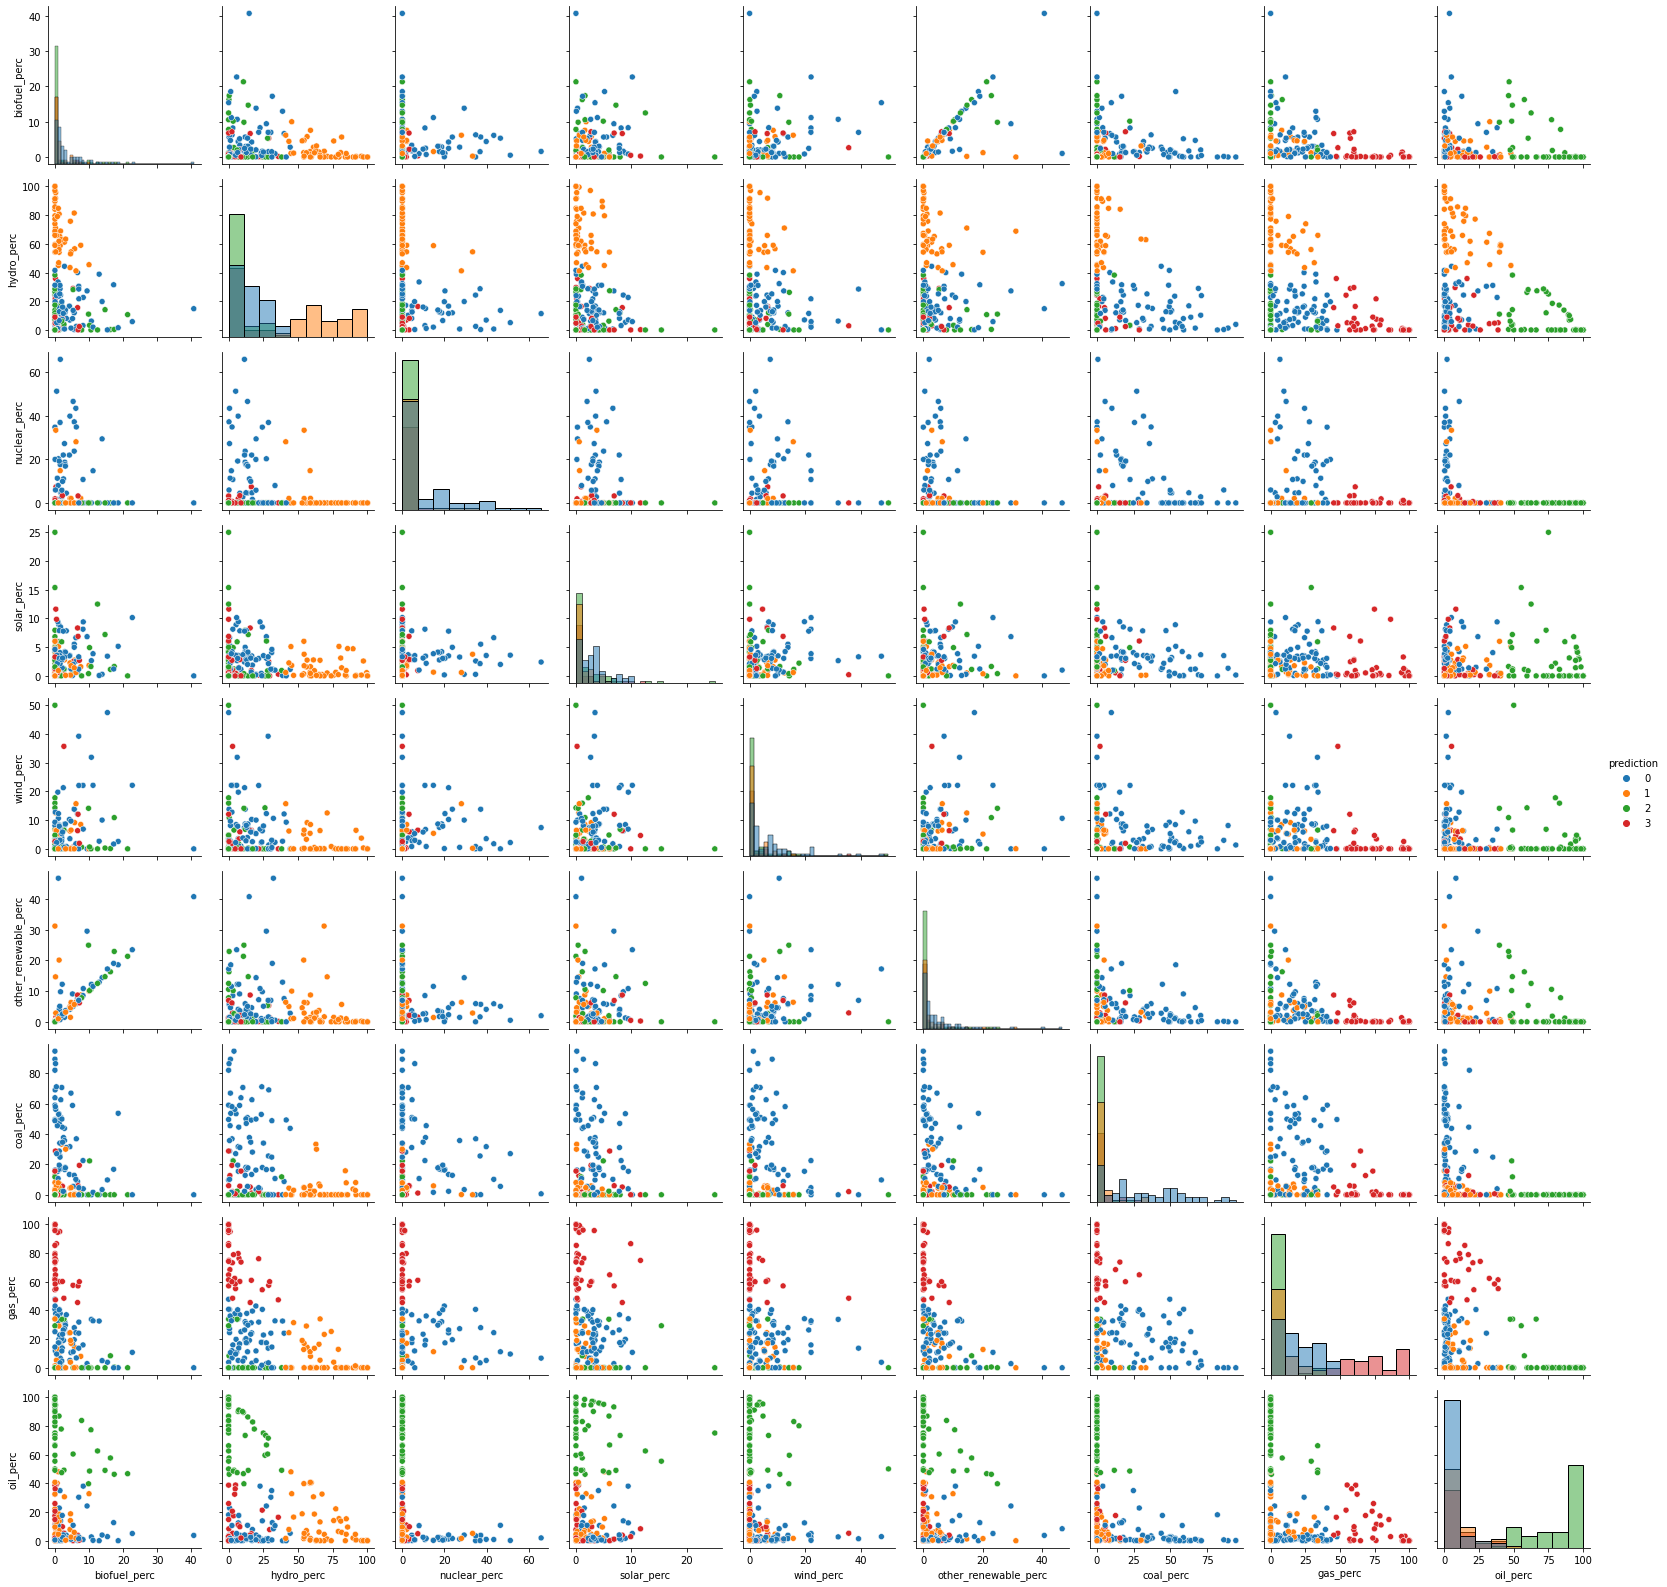

In [ ]:
import seaborn as sns
g = sns.PairGrid(clusters_data, hue="prediction", palette="tab10")
g.map_diag(sns.histplot)


g.map_offdiag(sns.scatterplot)
g.add_legend()

# REGRESSION

In [ ]:
data_regressione = data.filter((data.year>=2000)).select('country', 
           'year',
           'biofuel_electricity', 
           'hydro_electricity',
           'nuclear_electricity',
           'solar_electricity',
           'wind_electricity', 
           'other_renewable_electricity',
           'coal_electricity',
           'gas_electricity',
           'oil_electricity').alias("data_regressione")

data_test= data_regressione.filter((data_regressione.year>2019))
data_regressione = data_regressione.filter((data_regressione.year<2019))


In [ ]:
from pyspark.sql import Window
from pyspark.sql.functions import last
import sys

# define the window
window = Window.partitionBy('country')\
               .orderBy('year')\
               .rowsBetween(-sys.maxsize, 0)

# define the forward-filled column
filled_column_biofuel = last(data_regressione['biofuel_electricity'], ignorenulls=True).over(window)
filled_column_hydro = last(data_regressione['hydro_electricity'], ignorenulls=True).over(window)
filled_column_nuclear = last(data_regressione['nuclear_electricity'], ignorenulls=True).over(window)
filled_column_solar = last(data_regressione['solar_electricity'], ignorenulls=True).over(window)
filled_column_wind = last(data_regressione['wind_electricity'], ignorenulls=True).over(window)
filled_column_other_renewable = last(data_regressione['other_renewable_electricity'], ignorenulls=True).over(window)
filled_column_coal = last(data_regressione['coal_electricity'], ignorenulls=True).over(window)
filled_column_gas = last(data_regressione['gas_electricity'], ignorenulls=True).over(window)
filled_column_oil = last(data_regressione['oil_electricity'], ignorenulls=True).over(window)

# do the fill
data_regressione = data_regressione.withColumn('filled_column_biofuel', filled_column_biofuel)
data_regressione = data_regressione.withColumn('filled_column_hydro', filled_column_hydro)
data_regressione = data_regressione.withColumn('filled_column_nuclear', filled_column_nuclear)
data_regressione = data_regressione.withColumn('filled_column_solar', filled_column_solar)
data_regressione = data_regressione.withColumn('filled_column_wind', filled_column_wind)
data_regressione = data_regressione.withColumn('filled_column_other_renewable', filled_column_other_renewable)
data_regressione = data_regressione.withColumn('filled_column_coal', filled_column_coal)
data_regressione = data_regressione.withColumn('filled_column_gas', filled_column_gas)
data_regressione = data_regressione.withColumn('filled_column_oil', filled_column_oil)

data_regressione = data_regressione.withColumn('total', expr("filled_column_biofuel + filled_column_hydro + filled_column_nuclear + filled_column_solar+ filled_column_wind + filled_column_other_renewable + filled_column_coal + filled_column_gas + filled_column_oil "))




In [ ]:
from pyspark.sql.functions import round
data_regressione=data_regressione.withColumn('biofuel_perc', (round((100*(data_regressione.filled_column_biofuel/data_regressione.total)),2)))
data_regressione=data_regressione.withColumn('hydro_perc', (round((100*(data_regressione.filled_column_hydro/data_regressione.total)),2)))
data_regressione=data_regressione.withColumn('nuclear_perc', (round((100*(data_regressione.filled_column_nuclear/data_regressione.total)),2)))
data_regressione=data_regressione.withColumn('solar_perc', (round((100*(data_regressione.filled_column_solar/data_regressione.total)),2)))
data_regressione=data_regressione.withColumn('wind_perc', (round((100*(data_regressione.filled_column_wind/data_regressione.total)),2)))
data_regressione=data_regressione.withColumn('other_renewable_perc', (round((100*(data_regressione.filled_column_other_renewable/data_regressione.total)),2)))
data_regressione=data_regressione.withColumn('coal_perc', (round((100*(data_regressione.filled_column_coal/data_regressione.total)),2)))
data_regressione=data_regressione.withColumn('gas_perc', (round((100*(data_regressione.filled_column_gas/data_regressione.total)),2)))
data_regressione=data_regressione.withColumn('oil_perc', (round((100*(data_regressione.filled_column_oil/data_regressione.total)),2)))

In [ ]:
data_regressione = data_regressione.withColumn('renewable', expr("biofuel_perc + hydro_perc + nuclear_perc + solar_perc+ wind_perc + other_renewable_perc "))
data_regressione = data_regressione.withColumn('not_renewable', expr("coal_perc + gas_perc + oil_perc "))

In [ ]:
data_regressione=data_regressione.na.drop()

In [ ]:
data_regressione.describe().show()

+-------+-----------+------------------+-------------------+-----------------+-------------------+------------------+------------------+---------------------------+------------------+------------------+------------------+---------------------+-------------------+---------------------+-------------------+------------------+-----------------------------+------------------+------------------+------------------+------------------+-----------------+------------------+------------------+-------------------+------------------+--------------------+------------------+------------------+------------------+------------------+-----------------+
|summary|    country|              year|biofuel_electricity|hydro_electricity|nuclear_electricity| solar_electricity|  wind_electricity|other_renewable_electricity|  coal_electricity|   gas_electricity|   oil_electricity|filled_column_biofuel|filled_column_hydro|filled_column_nuclear|filled_column_solar|filled_column_wind|filled_column_other_renewable|fille

In [ ]:
from pyspark.ml.feature import VectorAssembler
assemble=VectorAssembler(inputCols=[
'biofuel_perc',
'hydro_perc',
'nuclear_perc',
'solar_perc',
'wind_perc',
'other_renewable_perc',
'coal_perc',
'gas_perc',
'oil_perc'],outputCol = 'energy_features')

assembled_data=assemble.transform(data_regressione)
assembled_data = assembled_data.select(['energy_features', 'renewable'])
assembled_data.show(5)

+--------------------+---------+
|     energy_features|renewable|
+--------------------+---------+
|(9,[1,8],[65.96,3...|    65.96|
|(9,[1,8],[84.75,1...|    84.75|
|(9,[1,8],[81.16,1...|    81.16|
|(9,[1,8],[67.02,3...|    67.02|
|(9,[1,8],[62.92,3...|    62.92|
+--------------------+---------+
only showing top 5 rows



In [ ]:
splits = assembled_data.randomSplit([0.7, 0.3])
train_df = splits[0]
test_df = splits[1]

In [ ]:
from pyspark.ml.regression import LinearRegression
lr = LinearRegression(featuresCol = 'energy_features', labelCol='renewable', maxIter=10, regParam=0.3, elasticNetParam=0.8)
lr_model = lr.fit(train_df)
print("Coefficients: " + str(lr_model.coefficients))
print("Intercept: " + str(lr_model.intercept))

Coefficients: [0.7451881635169564,0.7445050455806657,0.7293515526073737,0.516656213067833,0.6992933601969583,0.7024486576818361,-0.23833734117330943,-0.24601777660719915,-0.2511965095644033]
Intercept: 25.306435022782406


In [ ]:
trainingSummary = lr_model.summary
print("RMSE: %f" % trainingSummary.rootMeanSquaredError)
print("r2: %f" % trainingSummary.r2)

RMSE: 0.659227
r2: 0.999609


R squared at 0.999 indicates that in our model, approximate 99.9% of the variability in “Renewables” can be explained using the model. This is in align with the result from Scikit-Learn. It is good. However, we must be cautious that the performance on the training set may not a good approximation of the performance on the test set.

In [ ]:
lr_predictions = lr_model.transform(test_df)
lr_predictions.select("prediction","renewable","energy_features").show(5)
from pyspark.ml.evaluation import RegressionEvaluator
lr_evaluator = RegressionEvaluator(predictionCol="prediction", \
                 labelCol="renewable",metricName="r2")
print("R Squared (R2) on test data = %g" % lr_evaluator.evaluate(lr_predictions))

+-----------------+------------------+--------------------+
|       prediction|         renewable|     energy_features|
+-----------------+------------------+--------------------+
| 99.7614885024074|100.00999999999999|(9,[0,1,5],[0.07,...|
| 99.7614885024074|100.00999999999999|(9,[0,1,5],[0.07,...|
|71.12736386012054|              70.9|(9,[0,1,5,6],[0.6...|
|78.38872307273017| 78.34000000000002|(9,[0,1,5,6],[1.9...|
|72.55416056786126| 72.41999999999999|(9,[0,1,5,6],[2.3...|
+-----------------+------------------+--------------------+
only showing top 5 rows

R Squared (R2) on test data = 0.999607


In [ ]:
test_result = lr_model.evaluate(test_df)
print("Root Mean Squared Error (RMSE) on test data = %g" % test_result.rootMeanSquaredError)

Root Mean Squared Error (RMSE) on test data = 0.642372


In [ ]:
predictions = lr_model.transform(test_df)
predictions.select("prediction","renewable","energy_features").show()

+------------------+------------------+--------------------+
|        prediction|         renewable|     energy_features|
+------------------+------------------+--------------------+
|  99.7614885024074|100.00999999999999|(9,[0,1,5],[0.07,...|
|  99.7614885024074|100.00999999999999|(9,[0,1,5],[0.07,...|
| 71.12736386012054|              70.9|(9,[0,1,5,6],[0.6...|
| 78.38872307273017| 78.34000000000002|(9,[0,1,5,6],[1.9...|
| 72.55416056786126| 72.41999999999999|(9,[0,1,5,6],[2.3...|
| 59.03988238803383|             59.04|(9,[0,1,5,7],[3.5...|
|53.147094785140396|             53.11|(9,[0,1,5,7],[3.9...|
| 48.02266195914832|             48.15|(9,[0,1,5,7],[9.0...|
| 65.05736416104625|             65.62|(9,[0,1,5,7],[15....|
| 98.93298754813888|             99.18|(9,[0,1,5,8],[0.1...|
| 99.56734041453434|             99.82|(9,[0,1,5,8],[0.1...|
| 98.13871988346483| 98.39999999999999|(9,[0,1,5,8],[0.2...|
| 99.54207956537165|             99.79|(9,[0,1,5,8],[0.2...|
| 99.33005654099591| 99.

In [ ]:

prova_data=assemble.transform(data_regressione.filter((data_regressione.country=="Italy") & (data_regressione.year>2019)))
prova_data = prova_data.select(['energy_features', 'renewable'])
'''
prova=data_energia.filter(data_energia.country=="Italy").select('biofuel_perc',
'hydro_perc',
'nuclear_perc',
'solar_perc',
'wind_perc',
'other_renewable_perc',
'coal_perc',
'gas_perc',
'oil_perc').show()
'''


'\nprova=data_energia.filter(data_energia.country=="Italy").select(\'biofuel_perc\',\n\'hydro_perc\',\n\'nuclear_perc\',\n\'solar_perc\',\n\'wind_perc\',\n\'other_renewable_perc\',\n\'coal_perc\',\n\'gas_perc\',\n\'oil_perc\').show()\n'

In [ ]:
from pyspark.sql import Window
from pyspark.sql.functions import last
import sys

# define the window
window = Window.partitionBy('country')\
               .orderBy('year')\
               .rowsBetween(-sys.maxsize, 0)

# define the forward-filled column
filled_column_biofuel = last(data_test['biofuel_electricity'], ignorenulls=True).over(window)
filled_column_hydro = last(data_test['hydro_electricity'], ignorenulls=True).over(window)
filled_column_nuclear = last(data_test['nuclear_electricity'], ignorenulls=True).over(window)
filled_column_solar = last(data_test['solar_electricity'], ignorenulls=True).over(window)
filled_column_wind = last(data_test['wind_electricity'], ignorenulls=True).over(window)
filled_column_other_renewable = last(data_test['other_renewable_electricity'], ignorenulls=True).over(window)
filled_column_coal = last(data_test['coal_electricity'], ignorenulls=True).over(window)
filled_column_gas = last(data_test['gas_electricity'], ignorenulls=True).over(window)
filled_column_oil = last(data_test['oil_electricity'], ignorenulls=True).over(window)

# do the fill
data_test = data_test.withColumn('filled_column_biofuel', filled_column_biofuel)
data_test = data_test.withColumn('filled_column_hydro', filled_column_hydro)
data_test = data_test.withColumn('filled_column_nuclear', filled_column_nuclear)
data_test = data_test.withColumn('filled_column_solar', filled_column_solar)
data_test = data_test.withColumn('filled_column_wind', filled_column_wind)
data_test = data_test.withColumn('filled_column_other_renewable', filled_column_other_renewable)
data_test = data_test.withColumn('filled_column_coal', filled_column_coal)
data_test = data_test.withColumn('filled_column_gas', filled_column_gas)
data_test = data_test.withColumn('filled_column_oil', filled_column_oil)

data_test = data_test.withColumn('total', expr("filled_column_biofuel + filled_column_hydro + filled_column_nuclear + filled_column_solar+ filled_column_wind + filled_column_other_renewable + filled_column_coal + filled_column_gas + filled_column_oil "))


from pyspark.sql.functions import round
data_test=data_test.withColumn('biofuel_perc', (round((100*(data_test.filled_column_biofuel/data_test.total)),2)))
data_test=data_test.withColumn('hydro_perc', (round((100*(data_test.filled_column_hydro/data_test.total)),2)))
data_test=data_test.withColumn('nuclear_perc', (round((100*(data_test.filled_column_nuclear/data_test.total)),2)))
data_test=data_test.withColumn('solar_perc', (round((100*(data_test.filled_column_solar/data_test.total)),2)))
data_test=data_test.withColumn('wind_perc', (round((100*(data_test.filled_column_wind/data_test.total)),2)))
data_test=data_test.withColumn('other_renewable_perc', (round((100*(data_test.filled_column_other_renewable/data_test.total)),2)))
data_test=data_test.withColumn('coal_perc', (round((100*(data_test.filled_column_coal/data_test.total)),2)))
data_test=data_test.withColumn('gas_perc', (round((100*(data_test.filled_column_gas/data_test.total)),2)))
data_test=data_test.withColumn('oil_perc', (round((100*(data_test.filled_column_oil/data_test.total)),2)))

data_test = data_test.withColumn('renewable', expr("biofuel_perc + hydro_perc + nuclear_perc + solar_perc+ wind_perc + other_renewable_perc "))
data_test = data_test.withColumn('not_renewable', expr("coal_perc + gas_perc + oil_perc "))

data_test=data_test.na.drop()


prova_data=assemble.transform(data_test.filter((data_test.country=="Italy")))
prova_data = prova_data.select(['energy_features', 'renewable'])

In [ ]:
data_test.filter(data_test.country=="Italy").show()

+-------+----+-------------------+-----------------+-------------------+-----------------+----------------+---------------------------+----------------+---------------+---------------+---------------------+-------------------+---------------------+-------------------+------------------+-----------------------------+------------------+-----------------+-----------------+------------------+------------+----------+------------+----------+---------+--------------------+---------+--------+--------+-----------------+-------------+
|country|year|biofuel_electricity|hydro_electricity|nuclear_electricity|solar_electricity|wind_electricity|other_renewable_electricity|coal_electricity|gas_electricity|oil_electricity|filled_column_biofuel|filled_column_hydro|filled_column_nuclear|filled_column_solar|filled_column_wind|filled_column_other_renewable|filled_column_coal|filled_column_gas|filled_column_oil|             total|biofuel_perc|hydro_perc|nuclear_perc|solar_perc|wind_perc|other_renewable_perc

In [ ]:
predictions = lr_model.transform(prova_data)
predictions.select("prediction","renewable","energy_features").show()

+------------------+-----------------+--------------------+
|        prediction|        renewable|     energy_features|
+------------------+-----------------+--------------------+
| 43.31377484439797|45.56999999999999|[6.65,15.54,0.0,8...|
|42.016250110827876|            44.25|[6.53,14.18,0.0,8...|
+------------------+-----------------+--------------------+

